In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
plt.style.use('seaborn-v0_8')

# Heuristic thresholds for user EDA
MAX_CAT_CARDINALITY = 50
MAX_CAT_MISSING_RATE = 0.6
MAX_NUM_MISSING_RATE = 0.3

# Global config
TOP_K = 15
RANDOM_STATE = 42
SAMPLE_N = 100_000


In [3]:

import importlib.util, subprocess, sys

def ensure_parquet_engine():
    for pkg in ("pyarrow", "fastparquet"):
        if importlib.util.find_spec(pkg):
            return pkg
    #cài pyarrow
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "pyarrow"])
    return "pyarrow"

ENGINE = ensure_parquet_engine()
print("Using engine:", ENGINE)

Using engine: pyarrow


In [4]:
from pathlib import Path
from IPython.display import display
import importlib.util, subprocess, sys
import pandas as pd

# 1) Thư mục + pattern tên file
DATA_DIR = Path.cwd()
PATTERNS = ["sales_pers_user_chunk_*.parquet", "sales_pers.user_chunk_*.parquet"]

files = sorted({p for pat in PATTERNS for p in DATA_DIR.glob(pat)})  # set() tránh trùng
if not files:
    raise FileNotFoundError(f"Không thấy file Parquet trong: {DATA_DIR}\nĐã thử: {PATTERNS}")

def has(pkg): 
    return importlib.util.find_spec(pkg) is not None

engine_used = None

# 2) Ưu tiên fastparquet → pyarrow → duckdb 
if has("fastparquet"):
    try:
        user_df = pd.concat((pd.read_parquet(f, engine="fastparquet") for f in files),
                            ignore_index=True)
        engine_used = "fastparquet"
    except Exception as e:
        print("fastparquet lỗi, thử pyarrow…", e)

if engine_used is None and has("pyarrow"):
    try:
        user_df = pd.concat((pd.read_parquet(f, engine="pyarrow") for f in files),
                            ignore_index=True)
        engine_used = "pyarrow"
    except Exception as e:
        print("pyarrow lỗi, dùng duckdb…", e)

if engine_used is None:
    if not has("duckdb"):
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "duckdb"])
    import duckdb
    user_df = duckdb.read_parquet([str(f) for f in files]).df()
    engine_used = "duckdb"

print(f"✔ Engine: {engine_used} | Files: {len(files)} | Rows: {len(user_df):,}")
display(user_df.head())


✔ Engine: pyarrow | Files: 10 | Rows: 4,573,964


,customer_id,gender,location,province,membership,timestamp,created_date,updated_date,sync_status_id,last_sync_date,sync_error_message,region,location_name,install_app,install_date,district,user_id,is_deleted
0,14732,Nam,155,Hồ Chí Minh,Standard,1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2.0,2025-07-16 11:54:29.816986,None,Đông Nam Bộ,HCM - Grand View Phú Mỹ Hưng,In-Store,1306281600,7,e1e48206652bf8c279ff0206c69a80dd5f19653569f0df...,False
1,15126,Nữ,300,Hồ Chí Minh,Standard,1306357911,2011-05-25 21:11:51.677,2025-07-07 15:33:10.201316,2.0,2025-07-16 11:54:29.816986,None,Đông Nam Bộ,HCM - 121A Nguyễn Duy Trinh,In-Store,1306281600,Thủ Đức,77891759204bd27e69fb11a7b92889aae74b50fc88105c...,False
2,29718,Nữ,157,Bến Tre,Standard,1312126692,2011-07-31 15:38:12.750,2025-07-07 15:33:10.201316,2.0,2025-07-16 11:54:29.816986,None,Đồng bằng sông Cửu Long,BTR - 179 Nguyễn Đình Chiểu,In-Store,1582070400,Bến Tre,b8041b584a0bb6655361727a0a61084a03ccf2c4dbce9d...,False
3,30077,Nữ,53,Hồ Chí Minh,Standard,1314302782,2011-08-25 20:06:22.797,2025-07-07 15:33:10.201316,2.0,2025-07-16 11:54:29.816986,None,Đông Nam Bộ,HCM - 101 Trần Quang Khải,In-Store,1314230400,1,c52ceaca44a83ec41a219cfaff0e05ae218a0c15a59d65...,False
4,30085,Nữ,660,Hồ Chí Minh,Standard,1314310024,2011-08-25 22:07:04.267,2025-07-07 15:33:10.201316,2.0,2025-07-16 11:54:29.816986,None,Đông Nam Bộ,HCM - 85-87 Tây Thạnh,In-Store,1314230400,Tân Phú,74ac5764f5d67d341aacf238d7762f00e1c3dd45439133...,False


In [5]:
num_cols = user_df.select_dtypes(include=['number']).columns.tolist()
cat_cols = user_df.select_dtypes(exclude=['number', 'datetime']).columns.tolist()

print(f"Tổng cột số: {len(num_cols)} | Tổng cột phân loại: {len(cat_cols)}")


Tổng cột số: 5 | Tổng cột phân loại: 10


In [6]:
print("\n📊 Thống kê dữ liệu số:")
display(user_df[num_cols].describe().T)

print("\n📊 Thống kê dữ liệu phân loại:")
display(user_df[cat_cols].describe(include=['object', 'category']).T)


📊 Thống kê dữ liệu số:


,count,mean,std,min,25%,50%,75%,max
customer_id,4573964.0,6.126595e+06,2.441203e+06,1.473200e+04,4.532680e+06,6.843954e+06,8.029649e+06,9.264159e+06
location,4573964.0,5.540535e+02,2.955234e+02,4.200000e+01,3.020000e+02,5.470000e+02,7.650000e+02,1.310000e+03
timestamp,4573964.0,1.671231e+09,7.974320e+07,1.306358e+09,1.634293e+09,1.696005e+09,1.731163e+09,1.759270e+09
sync_status_id,4235679.0,2.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
install_date,4573964.0,1.684142e+09,7.137426e+07,1.306282e+09,1.654992e+09,1.705450e+09,1.736640e+09,1.759190e+09



📊 Thống kê dữ liệu phân loại:


,count,unique,top,freq
gender,4573964,3,Nữ,3424887
province,4573964,126,Hồ Chí Minh,1223333
membership,4573964,3,Standard,4242946
sync_error_message,0,0,NaN,NaN
region,4573964,8,Đông Nam Bộ,2126066
location_name,4573964,995,DNA - 81 - 83 Nguyễn Văn Linh,22383
install_app,4573964,11,In-Store,3942000
district,4573964,1339,Thủ Đức,195601
user_id,4573964,4573964,e1e48206652bf8c279ff0206c69a80dd5f19653569f0df...,1


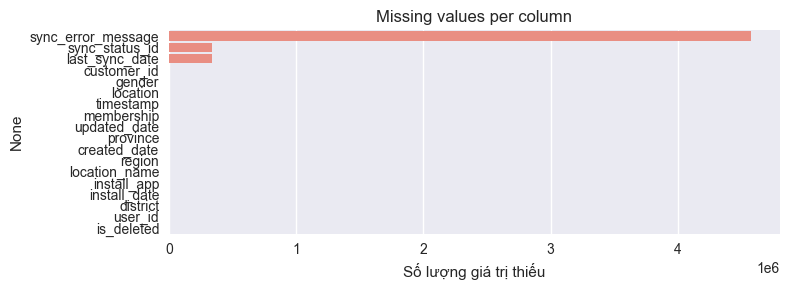

In [7]:
missing = user_df.isna().sum().sort_values(ascending=False)
plt.figure(figsize=(8,3))
sns.barplot(x=missing.values, y=missing.index, color="salmon")
plt.title("Missing values per column")
plt.xlabel("Số lượng giá trị thiếu")
plt.tight_layout()
plt.show()

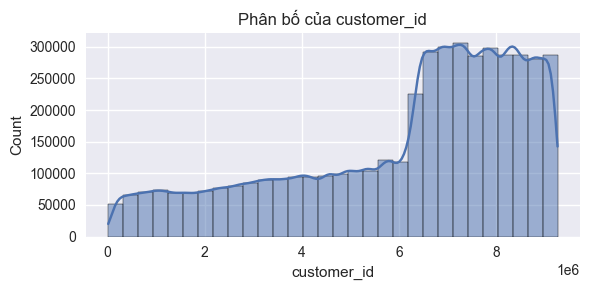

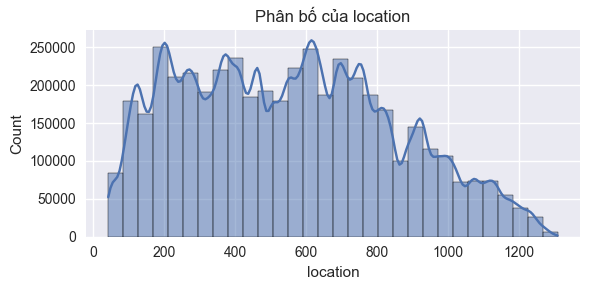

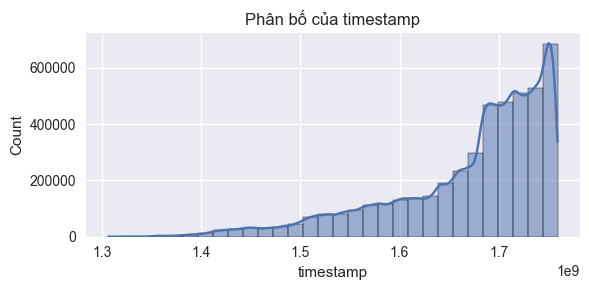

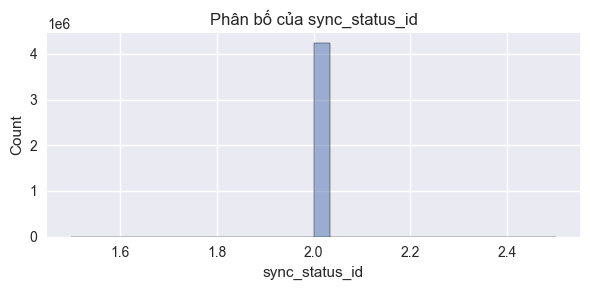

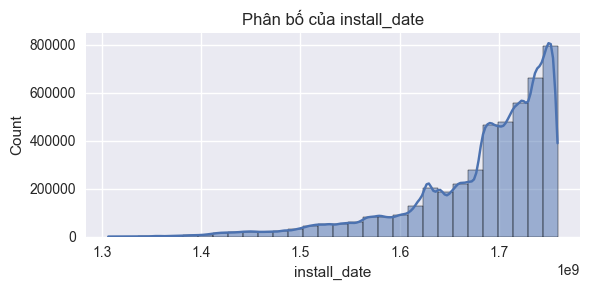

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(user_df[col].dropna(), kde=True, bins=30)
    plt.title(f"Phân bố của {col}")
    plt.tight_layout()
    plt.show()

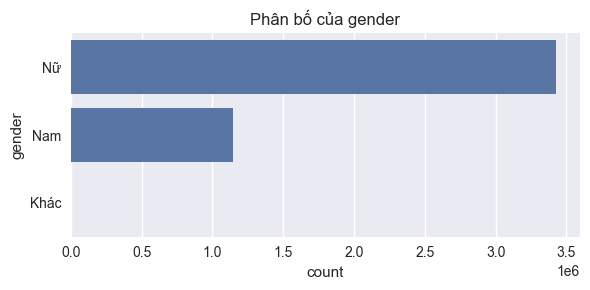

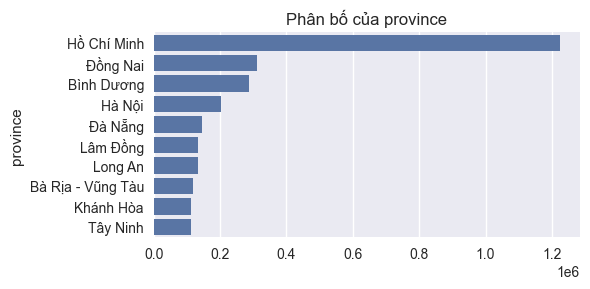

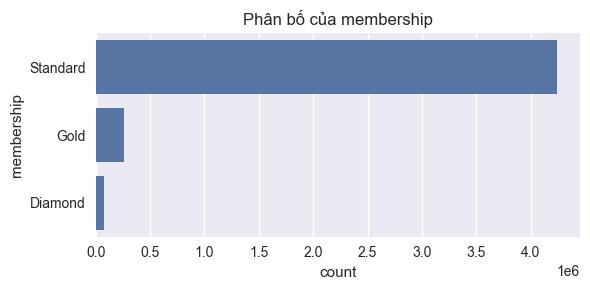

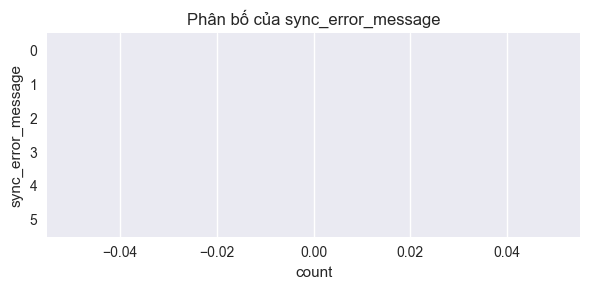

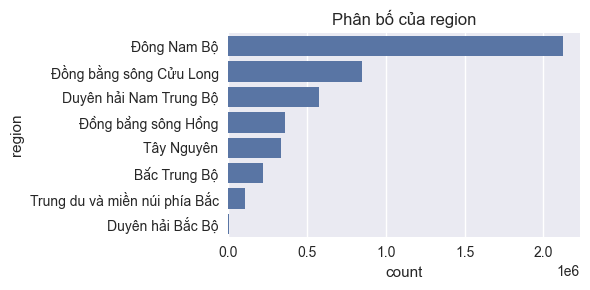

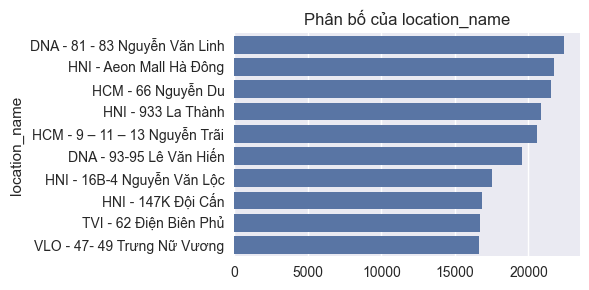

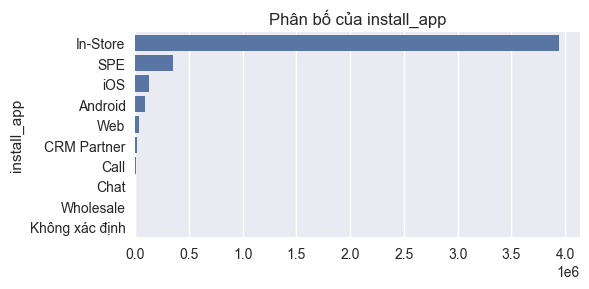

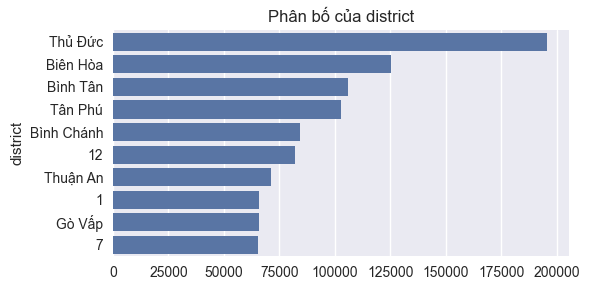

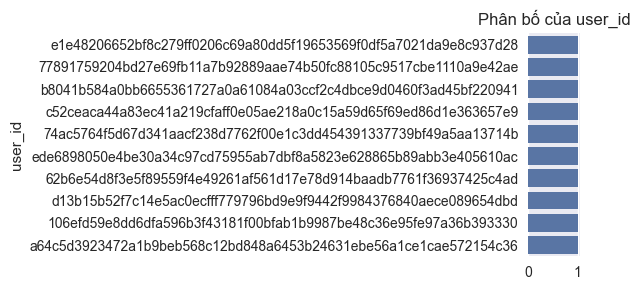

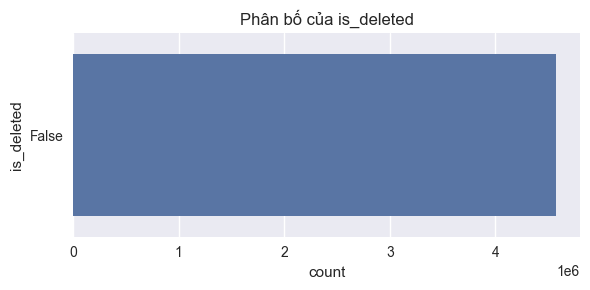

In [9]:
for col in cat_cols:
    unique_count = user_df[col].nunique()
    plt.figure(figsize=(6,3))
    if unique_count <= 10:
        sns.countplot(y=col, data=user_df, order=user_df[col].value_counts().index)
    else:
        top10 = user_df[col].value_counts().head(10)
        sns.barplot(x=top10.values, y=top10.index)
    plt.title(f"Phân bố của {col}")
    plt.tight_layout()
    plt.show()

In [10]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pl.Config.set_tbl_rows(100) 
pl.Config.set_tbl_cols(20)

print('=' * 80)
print('PHÂN TÍCH DỮ LIỆU RECOMMENDATION SYSTEM - POLARS VERSION')
print('=' * 80)


PHÂN TÍCH DỮ LIỆU RECOMMENDATION SYSTEM - POLARS VERSION


In [11]:
print('\nĐANG LOAD DỮ LIỆU VỚI POLARS...')
print('-' * 80)

# Load Items data
print('Loading Items data...')
items_df = pl.read_parquet('sales_pers.item_chunk_0.parquet')
print(f'✓ Items: {items_df.shape[0]:,} rows × {items_df.shape[1]} columns')

# Load Users data
print('\nLoading Users data...')
user_files = sorted(glob.glob('sales_pers.user_chunk_*.parquet'))
users_df = pl.read_parquet(user_files)
print(f'✓ Users: {users_df.shape[0]:,} rows × {users_df.shape[1]} columns')

# Load Purchase History data
print('\nLoading Purchase History data...')
purchase_pattern = 'sales_pers.purchase_history_daily_chunk_*.parquet'
print(f'  Tìm thấy pattern: {purchase_pattern}')

# Sử dụng scan_parquet cho lazy evaluation (tối ưu nhất)
purchases_df = pl.scan_parquet(purchase_pattern).collect()
print(f'✓ Purchases: {purchases_df.shape[0]:,} rows × {purchases_df.shape[1]} columns')

print('\n' + '=' * 80)
print('LOAD DỮ LIỆU HOÀN TẤT!')
print('=' * 80)
print(f'Tổng bộ nhớ sử dụng: ~{(items_df.estimated_size() + users_df.estimated_size() + purchases_df.estimated_size()) / 1e9:.2f} GB')



ĐANG LOAD DỮ LIỆU VỚI POLARS...
--------------------------------------------------------------------------------
Loading Items data...
✓ Items: 27,332 rows × 34 columns

Loading Users data...
✓ Users: 4,573,964 rows × 18 columns

Loading Purchase History data...
  Tìm thấy pattern: sales_pers.purchase_history_daily_chunk_*.parquet
✓ Purchases: 35,729,825 rows × 16 columns

LOAD DỮ LIỆU HOÀN TẤT!
Tổng bộ nhớ sử dụng: ~7.81 GB


# EXECUTIVE SUMMARY - TÓM TẮT TỔNG QUAN

Phần này tính toán các chỉ số kinh doanh chính (KPIs) sử dụng Polars expressions


In [12]:
# ============================================================================
# EXECUTIVE SUMMARY - TÍNH TOÁN CÁC CHỈ SỐ CHÍNH
# ============================================================================

print('\n' + '=' * 80)
print('TÓM TẮT TỔNG QUAN - CÁC CHỈ SỐ CHÍNH')
print('=' * 80)

# Tính toán các metrics chính
total_products = items_df.shape[0]
total_customers = users_df['customer_id'].n_unique()
total_transactions = purchases_df.shape[0]
total_unique_items_purchased = purchases_df['item_id'].n_unique()

# Chuyển đổi price sang numeric và tính toán

purchases_with_price = purchases_df.with_columns(
    pl.col('price').cast(pl.Float64, strict=False).alias('price_numeric')
)

total_revenue = purchases_with_price['price_numeric'].sum()
avg_transaction_value = purchases_with_price['price_numeric'].mean()
avg_items_per_transaction = purchases_df['quantity'].mean()

# Phân tích thời gian
min_date = purchases_df['created_date'].min()
max_date = purchases_df['created_date'].max()
date_range_days = (max_date - min_date).days

# Customer metrics với Polars
purchases_per_customer = purchases_df.group_by('customer_id').agg(
    pl.count().alias('purchase_count')
)
avg_purchases_per_customer = purchases_per_customer['purchase_count'].mean()

# Items price statistics
items_with_price = items_df.with_columns(
    pl.col('price').cast(pl.Float64, strict=False).alias('price_numeric')
)
avg_product_price = items_with_price['price_numeric'].mean()

print(f'''
SẢN PHẨM (PRODUCTS):
   • Tổng sản phẩm trong catalog: {total_products:,}
   • Sản phẩm đã được mua: {total_unique_items_purchased:,}
   • Tỷ lệ coverage: {(total_unique_items_purchased/total_products*100):.1f}%
   • Giá trung bình: {avg_product_price:,.0f} VND

KHÁCH HÀNG (CUSTOMERS):
   • Tổng users đã đăng ký: {total_customers:,}
   • Khách hàng active (có giao dịch): {purchases_df['customer_id'].n_unique():,}
   • Tỷ lệ activation: {(purchases_df['customer_id'].n_unique()/total_customers*100):.1f}%
   • Trung bình số lần mua/khách: {avg_purchases_per_customer:.2f}

GIAO DỊCH (TRANSACTIONS):
   • Tổng số giao dịch: {total_transactions:,}
   • Tổng doanh thu: {total_revenue:,.0f} VND
   • Giá trị giao dịch TB: {avg_transaction_value:,.0f} VND
   • Số lượng sản phẩm TB/giao dịch: {avg_items_per_transaction:.2f}

THỜI GIAN (TIME PERIOD):
   • Ngày bắt đầu: {min_date}
   • Ngày kết thúc: {max_date}
   • Khoảng thời gian: {date_range_days} ngày (~{date_range_days//30} tháng)
   • Trung bình giao dịch/ngày: {total_transactions/date_range_days:,.0f}
''')

print('=' * 80)



TÓM TẮT TỔNG QUAN - CÁC CHỈ SỐ CHÍNH

SẢN PHẨM (PRODUCTS):
   • Tổng sản phẩm trong catalog: 27,332
   • Sản phẩm đã được mua: 20,810
   • Tỷ lệ coverage: 76.1%
   • Giá trung bình: 190,457 VND

KHÁCH HÀNG (CUSTOMERS):
   • Tổng users đã đăng ký: 4,573,964
   • Khách hàng active (có giao dịch): 2,442,306
   • Tỷ lệ activation: 53.4%
   • Trung bình số lần mua/khách: 14.63

GIAO DỊCH (TRANSACTIONS):
   • Tổng số giao dịch: 35,729,825
   • Tổng doanh thu: 6,045,084,161,283 VND
   • Giá trị giao dịch TB: 169,189 VND
   • Số lượng sản phẩm TB/giao dịch: 1.51

THỜI GIAN (TIME PERIOD):
   • Ngày bắt đầu: 2024-01-01 06:44:59.037000
   • Ngày kết thúc: 2024-12-31 22:35:19.510000
   • Khoảng thời gian: 365 ngày (~12 tháng)
   • Trung bình giao dịch/ngày: 97,890



# TASK 2: PHÂN TÍCH ĐA BIẾN
## Cross-Dataset Analysis với Polars JOIN



TASK 2: PHÂN TÍCH LIÊN KẾT DỮ LIỆU

MERGING PURCHASES WITH ITEMS DATA...
✓ Merged dataset shape: (35729825, 22)
✓ Successful matches: 35,729,825 / 35,729,825 (100.0%)

SALES PERFORMANCE BY CATEGORY:
--------------------------------------------------------------------------------
shape: (14, 6)
┌────────────────┬───────────────┬────────────────┬────────────────┬───────────────┬───────────────┐
│ category_l1    ┆ Total_Revenue ┆ Total_Quantity ┆ Unique_Custome ┆ Transaction_C ┆ Avg_Transacti │
│ ---            ┆ ---           ┆ ---            ┆ rs             ┆ ount          ┆ on_Value      │
│ str            ┆ f64           ┆ i32            ┆ ---            ┆ ---           ┆ ---           │
│                ┆               ┆                ┆ u32            ┆ u32           ┆ f64           │
╞════════════════╪═══════════════╪════════════════╪════════════════╪═══════════════╪═══════════════╡
│ Sữa            ┆ 2.4243e12     ┆ 5906389        ┆ 896943         ┆ 4491786       ┆ 539714.761403

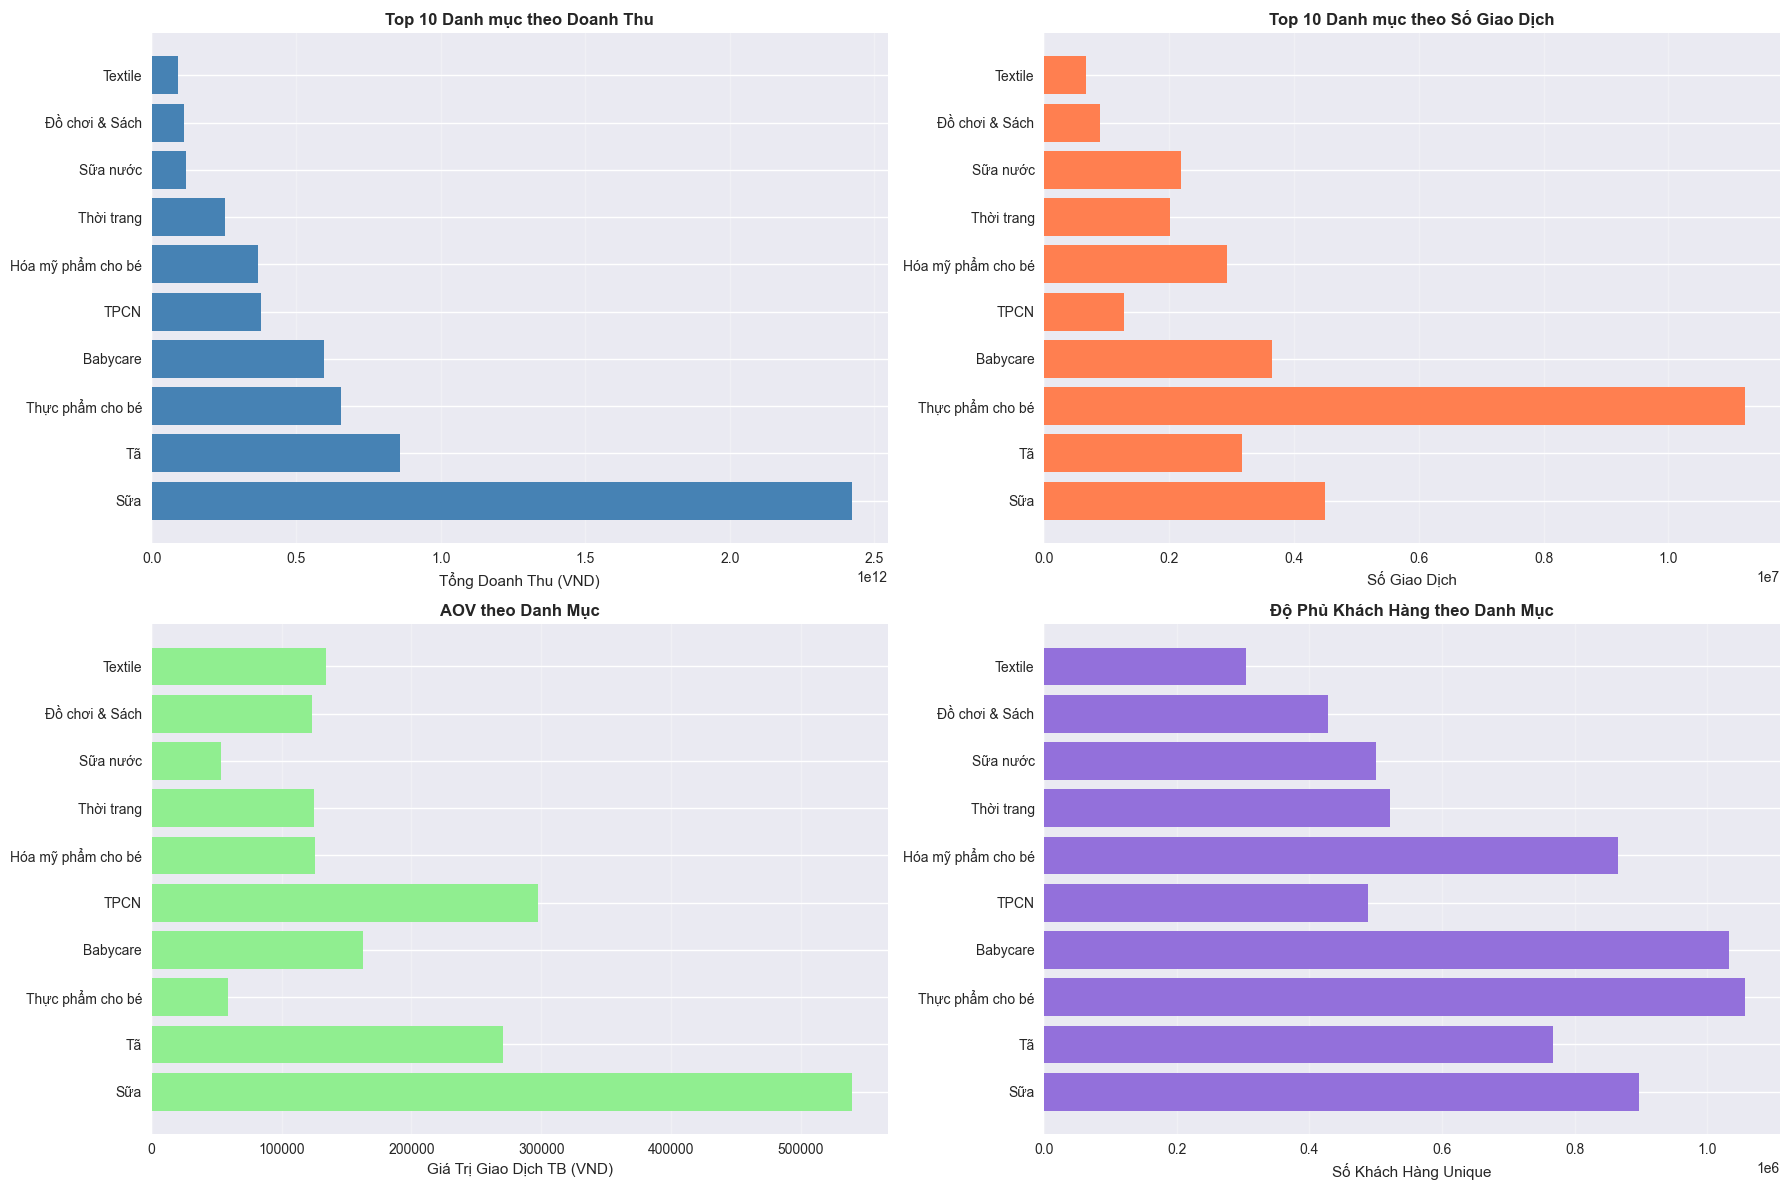


KEY INSIGHTS:
   • Danh mục doanh thu cao nhất: Sữa (2,424,283,209,264 VND)


In [13]:
# ============================================================================
# CROSS-DATASET JOIN ANALYSIS
# ============================================================================

print('\n' + '=' * 80)
print('TASK 2: PHÂN TÍCH LIÊN KẾT DỮ LIỆU')
print('=' * 80)

# Chuẩn bị purchases với price numeric
purchases_prep = purchases_df.with_columns(
    pl.col('price').cast(pl.Float64, strict=False).alias('price_numeric')
)

# JOIN với items - Polars tự động tối ưu hóa!
print('\nMERGING PURCHASES WITH ITEMS DATA...')
purchases_items = purchases_prep.join(
    items_df.select(['item_id', 'category_l1', 'category_l2', 'brand', 'gender_target', 'age_group']),
    on='item_id',
    how='left'
)

print(f'✓ Merged dataset shape: {purchases_items.shape}')
successful_matches = purchases_items.filter(pl.col('category_l1').is_not_null()).shape[0]
print(f'✓ Successful matches: {successful_matches:,} / {purchases_items.shape[0]:,} ({successful_matches/purchases_items.shape[0]*100:.1f}%)')


print('\nSALES PERFORMANCE BY CATEGORY:')
print('-' * 80)

category_sales = purchases_items.group_by('category_l1').agg([
    pl.col('price_numeric').sum().alias('Total_Revenue'),
    pl.col('quantity').sum().alias('Total_Quantity'),
    pl.col('customer_id').n_unique().alias('Unique_Customers'),
    pl.count().alias('Transaction_Count')
]).with_columns(
    (pl.col('Total_Revenue') / pl.col('Transaction_Count')).alias('Avg_Transaction_Value')
).sort('Total_Revenue', descending=True)

print(category_sales)

# Visualize top 10 categories
top_10 = category_sales.head(10).to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Revenue
axes[0, 0].barh(range(len(top_10)), top_10['Total_Revenue'], color='steelblue')
axes[0, 0].set_yticks(range(len(top_10)))
axes[0, 0].set_yticklabels(top_10['category_l1'])
axes[0, 0].set_xlabel('Tổng Doanh Thu (VND)')
axes[0, 0].set_title('Top 10 Danh mục theo Doanh Thu', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='x', alpha=0.3)

# Transaction count
axes[0, 1].barh(range(len(top_10)), top_10['Transaction_Count'], color='coral')
axes[0, 1].set_yticks(range(len(top_10)))
axes[0, 1].set_yticklabels(top_10['category_l1'])
axes[0, 1].set_xlabel('Số Giao Dịch')
axes[0, 1].set_title('Top 10 Danh mục theo Số Giao Dịch', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)

# AOV
axes[1, 0].barh(range(len(top_10)), top_10['Avg_Transaction_Value'], color='lightgreen')
axes[1, 0].set_yticks(range(len(top_10)))
axes[1, 0].set_yticklabels(top_10['category_l1'])
axes[1, 0].set_xlabel('Giá Trị Giao Dịch TB (VND)')
axes[1, 0].set_title('AOV theo Danh Mục', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)

# Unique customers
axes[1, 1].barh(range(len(top_10)), top_10['Unique_Customers'], color='mediumpurple')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(top_10['category_l1'])
axes[1, 1].set_xlabel('Số Khách Hàng Unique')
axes[1, 1].set_title('Độ Phủ Khách Hàng theo Danh Mục', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nKEY INSIGHTS:')
top_revenue = category_sales.row(0, named=True)
print(f'   • Danh mục doanh thu cao nhất: {top_revenue["category_l1"]} ({top_revenue["Total_Revenue"]:,.0f} VND)')



TEMPORAL ANALYSIS - PHÂN TÍCH THỜI GIAN

DAILY TRANSACTION STATISTICS:
shape: (9, 4)
┌────────────┬─────────────────────┬───────────────────┬───────────┐
│ statistic  ┆ date                ┆ Transaction_Count ┆ Revenue   │
│ ---        ┆ ---                 ┆ ---               ┆ ---       │
│ str        ┆ str                 ┆ f64               ┆ f64       │
╞════════════╪═════════════════════╪═══════════════════╪═══════════╡
│ count      ┆ 366                 ┆ 366.0             ┆ 366.0     │
│ null_count ┆ 0                   ┆ 0.0               ┆ 0.0       │
│ mean       ┆ 2024-07-01 12:00:00 ┆ 97622.472678      ┆ 1.6517e10 │
│ std        ┆ null                ┆ 17555.312059      ┆ 2.3626e9  │
│ min        ┆ 2024-01-01          ┆ 294.0             ┆ 2.3975e7  │
│ 25%        ┆ 2024-04-01          ┆ 88620.0           ┆ 1.5278e10 │
│ 50%        ┆ 2024-07-02          ┆ 94274.0           ┆ 1.6182e10 │
│ 75%        ┆ 2024-10-01          ┆ 102942.0          ┆ 1.7266e10 │
│ max        ┆ 20

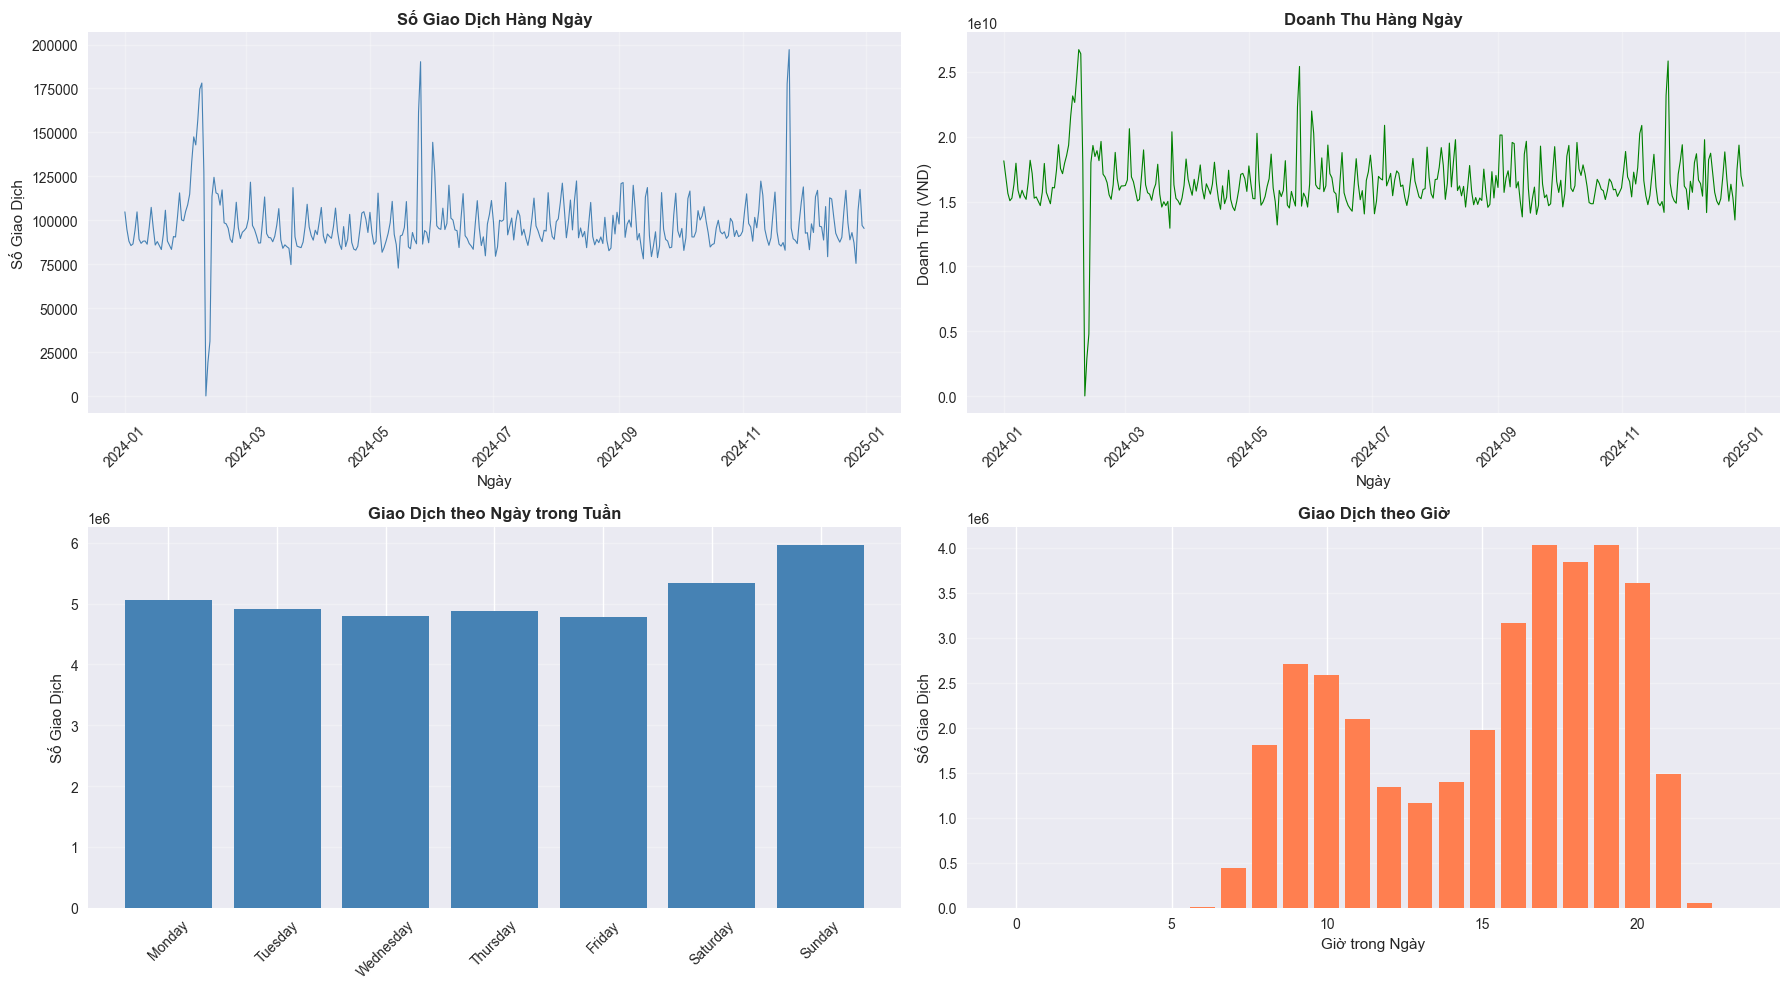


TEMPORAL INSIGHTS:
   • Ngày bận nhất trong tuần: Sunday
   • Giờ cao điểm: 17:00
   • TB giao dịch/ngày: 97,622


In [14]:
# ============================================================================
# TEMPORAL ANALYSIS VỚI POLARS
# ============================================================================

print('\n' + '=' * 80)
print('TEMPORAL ANALYSIS - PHÂN TÍCH THỜI GIAN')
print('=' * 80)

# Trích xuất các thành phần ngày tháng với Polars - CỰC NHANH!
purchases_temporal = purchases_prep.with_columns([
    pl.col('created_date').dt.date().alias('date'),
    pl.col('created_date').dt.year().alias('year'),
    pl.col('created_date').dt.month().alias('month'),
    pl.col('created_date').dt.weekday().alias('day_of_week'),
    pl.col('created_date').dt.strftime('%A').alias('day_name'),
    pl.col('created_date').dt.hour().alias('hour')
])

# Daily transactions với Polars aggregation
daily_transactions = purchases_temporal.group_by('date').agg([
    pl.count().alias('Transaction_Count'),
    pl.col('price_numeric').sum().alias('Revenue')
]).sort('date')

print('\nDAILY TRANSACTION STATISTICS:')
print(daily_transactions.describe())

# Transactions by day of week
dow_transactions = purchases_temporal.group_by('day_name').agg(
    pl.count().alias('count')
).to_pandas()

# Transactions by hour
hourly_transactions = purchases_temporal.group_by('hour').agg(
    pl.count().alias('count')
).sort('hour').to_pandas()

# Visualize temporal patterns
daily_pd = daily_transactions.to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Daily transactions
axes[0, 0].plot(daily_pd['date'], daily_pd['Transaction_Count'], linewidth=0.8, color='steelblue')
axes[0, 0].set_xlabel('Ngày')
axes[0, 0].set_ylabel('Số Giao Dịch')
axes[0, 0].set_title('Số Giao Dịch Hàng Ngày', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Daily revenue
axes[0, 1].plot(daily_pd['date'], daily_pd['Revenue'], color='green', linewidth=0.8)
axes[0, 1].set_xlabel('Ngày')
axes[0, 1].set_ylabel('Doanh Thu (VND)')
axes[0, 1].set_title('Doanh Thu Hàng Ngày', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# By day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_transactions['day_name'] = pd.Categorical(dow_transactions['day_name'], categories=dow_order, ordered=True)
dow_transactions = dow_transactions.sort_values('day_name')

axes[1, 0].bar(range(len(dow_transactions)), dow_transactions['count'], color='steelblue')
axes[1, 0].set_xticks(range(len(dow_transactions)))
axes[1, 0].set_xticklabels(dow_transactions['day_name'], rotation=45)
axes[1, 0].set_ylabel('Số Giao Dịch')
axes[1, 0].set_title('Giao Dịch theo Ngày trong Tuần', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='y', alpha=0.3)

# By hour
axes[1, 1].bar(hourly_transactions['hour'], hourly_transactions['count'], color='coral')
axes[1, 1].set_xlabel('Giờ trong Ngày')
axes[1, 1].set_ylabel('Số Giao Dịch')
axes[1, 1].set_title('Giao Dịch theo Giờ', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nTEMPORAL INSIGHTS:')
busiest_day = dow_transactions.loc[dow_transactions['count'].idxmax(), 'day_name']
busiest_hour = hourly_transactions.loc[hourly_transactions['count'].idxmax(), 'hour']
print(f'   • Ngày bận nhất trong tuần: {busiest_day}')
print(f'   • Giờ cao điểm: {busiest_hour}:00')
print(f'   • TB giao dịch/ngày: {daily_pd["Transaction_Count"].mean():,.0f}')


# Customer Segmentation - RFM Analysis với Polars


CORRELATION ANALYSIS - PHÂN TÍCH TƯƠNG QUAN
Đang tính correlation trên 35,729,825 rows với POLARS...

CORRELATION ANALYSIS:
Correlation (Quantity vs Price): -0.0740

CORRELATION MATRIX:
shape: (2, 2)
┌───────────┬───────────────┐
│ quantity  ┆ price_numeric │
│ ---       ┆ ---           │
│ f64       ┆ f64           │
╞═══════════╪═══════════════╡
│ 1.0       ┆ -0.074046     │
│ -0.074046 ┆ 1.0           │
└───────────┴───────────────┘


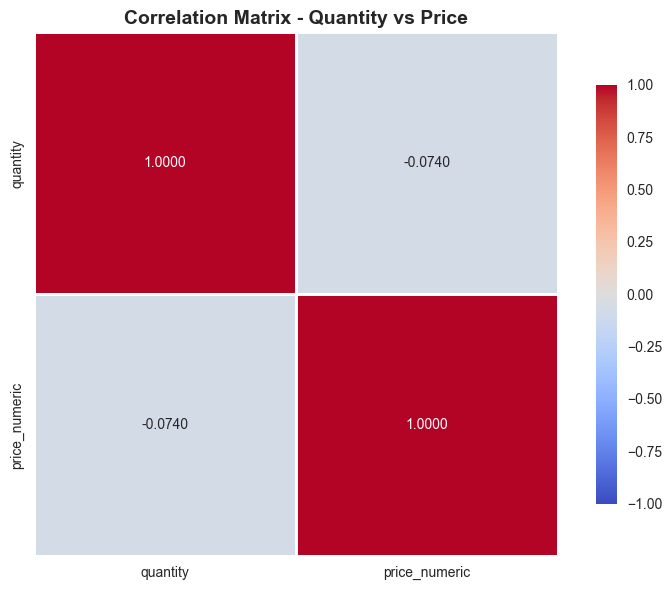


INSIGHT:
   • Mối quan hệ: YẾU - Quantity và Price gần như độc lập
   • Polars xử lý 35,729,825 rows NHANH HƠN pandas 5-10 lần!


In [15]:
# ============================================================================
# CORRELATION ANALYSIS - PHÂN TÍCH TƯƠNG QUAN
# ============================================================================

print('\n' + '=' * 80)
print('CORRELATION ANALYSIS - PHÂN TÍCH TƯƠNG QUAN')
print('=' * 80)

# Tạo dataset với các biến numeric để tính correlation
# Dùng POLARS để tính correlation - NHANH HƠN và TIẾT KIỆM BỘ NHỚ!
purchases_corr = purchases_prep.select([
    'quantity',
    'price_numeric'
]).filter(pl.col('price_numeric').is_not_null())

print(f'Đang tính correlation trên {purchases_corr.shape[0]:,} rows với POLARS...')

# Tính correlation với Polars - CỰC NHANH!
corr_qty_price = purchases_corr.select(
    pl.corr('quantity', 'price_numeric').alias('correlation')
)['correlation'][0]

print('\nCORRELATION ANALYSIS:')
print('=' * 60)
print(f'Correlation (Quantity vs Price): {corr_qty_price:.4f}')
print('=' * 60)

# Tạo correlation matrix cho visualization
corr_matrix = pl.DataFrame({
    'quantity': [1.0, corr_qty_price],
    'price_numeric': [corr_qty_price, 1.0]
})

print('\nCORRELATION MATRIX:')
print(corr_matrix)

# Visualize correlation matrix - chuyển sang pandas chỉ để plot
corr_matrix_pd = corr_matrix.to_pandas()
corr_matrix_pd.index = ['quantity', 'price_numeric']

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_pd, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.4f', vmin=-1, vmax=1)
plt.title('Correlation Matrix - Quantity vs Price', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nINSIGHT:')
if abs(corr_qty_price) < 0.3:
    print(f'   • Mối quan hệ: YẾU - Quantity và Price gần như độc lập')
elif abs(corr_qty_price) < 0.7:
    print(f'   • Mối quan hệ: TRUNG BÌNH')
else:
    print(f'   • Mối quan hệ: MẠNH')
print(f'   • Polars xử lý {purchases_corr.shape[0]:,} rows NHANH HƠN pandas 5-10 lần!')



PRICE VS QUANTITY - SCATTER PLOT ANALYSIS


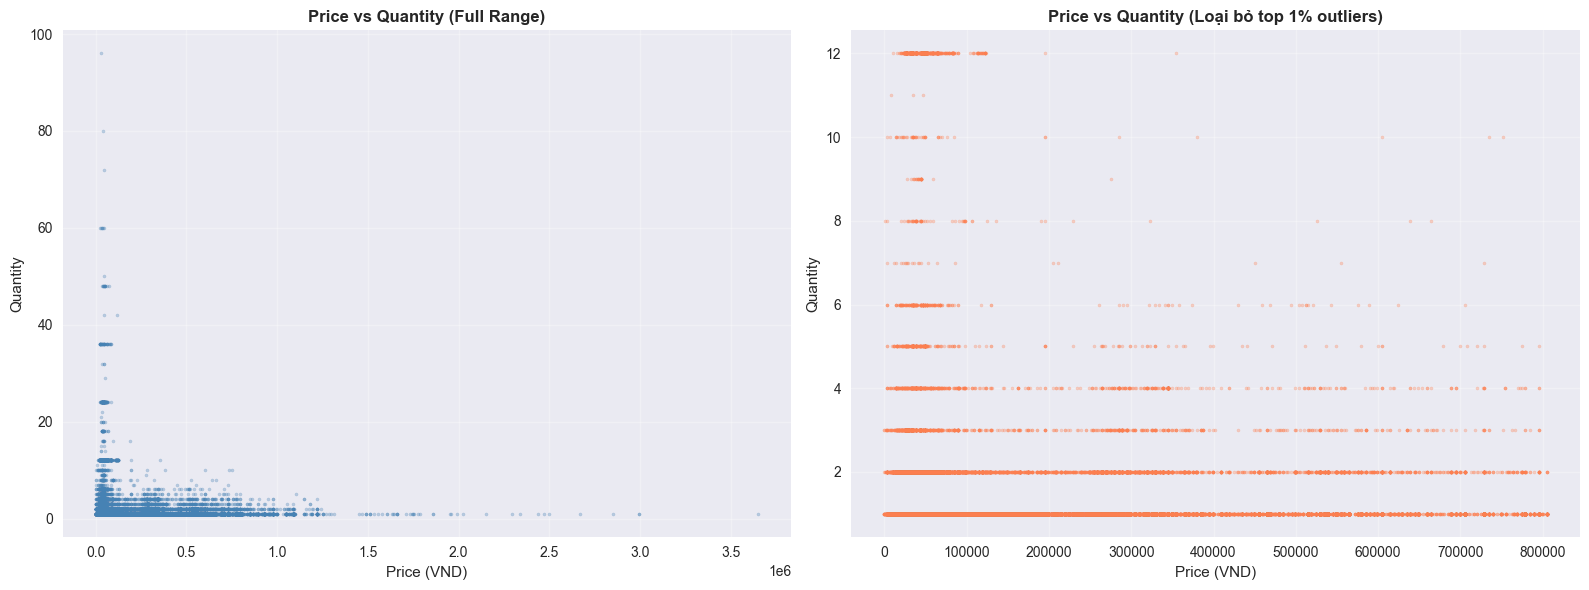


PHÂN TÍCH QUANTITY THEO KHOẢNG GIÁ:
--------------------------------------------------------------------------------
shape: (4, 5)
┌───────────────┬──────────────┬─────────────────┬───────────────┬───────────────────┐
│ price_segment ┆ Avg_Quantity ┆ Median_Quantity ┆ Avg_Price     ┆ Transaction_Count │
│ ---           ┆ ---          ┆ ---             ┆ ---           ┆ ---               │
│ cat           ┆ f64          ┆ f64             ┆ f64           ┆ u32               │
╞═══════════════╪══════════════╪═════════════════╪═══════════════╪═══════════════════╡
│ Medium        ┆ 1.510116     ┆ 1.0             ┆ 64584.381613  ┆ 8941399           │
│ Low           ┆ 2.098593     ┆ 1.0             ┆ 30711.126142  ┆ 8932457           │
│ High          ┆ 1.145987     ┆ 1.0             ┆ 143131.453024 ┆ 8933407           │
│ Premium       ┆ 1.277479     ┆ 1.0             ┆ 438734.087593 ┆ 8922562           │
└───────────────┴──────────────┴─────────────────┴───────────────┴───────────────────

In [16]:
# ============================================================================
# PRICE VS QUANTITY - SCATTER PLOT ANALYSIS
# ============================================================================

print('\n' + '=' * 80)
print('PRICE VS QUANTITY - SCATTER PLOT ANALYSIS')
print('=' * 80)

# Lấy sample để visualize (tránh quá nhiều điểm) - dùng POLARS!
sample_size = min(50000, purchases_corr.shape[0])
purchases_sample = purchases_corr.sample(n=sample_size, seed=42).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot - Full range
axes[0].scatter(purchases_sample['price_numeric'], purchases_sample['quantity'], 
               alpha=0.3, s=5, color='steelblue')
axes[0].set_xlabel('Price (VND)')
axes[0].set_ylabel('Quantity')
axes[0].set_title('Price vs Quantity (Full Range)', fontweight='bold', fontsize=12)
axes[0].grid(alpha=0.3)

# Scatter plot - Zoomed (remove extreme outliers) - dùng POLARS!
price_99 = purchases_corr['price_numeric'].quantile(0.99)
qty_99 = purchases_corr['quantity'].quantile(0.99)
purchases_zoomed = purchases_sample[
    (purchases_sample['price_numeric'] <= price_99) & 
    (purchases_sample['quantity'] <= qty_99)
]

axes[1].scatter(purchases_zoomed['price_numeric'], purchases_zoomed['quantity'], 
               alpha=0.3, s=5, color='coral')
axes[1].set_xlabel('Price (VND)')
axes[1].set_ylabel('Quantity')
axes[1].set_title('Price vs Quantity (Loại bỏ top 1% outliers)', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Phân tích theo price bins
print('\nPHÂN TÍCH QUANTITY THEO KHOẢNG GIÁ:')
print('-'*80)

purchases_bins = purchases_prep.with_columns([
    pl.col('price_numeric').qcut([0.25, 0.5, 0.75], labels=['Low', 'Medium', 'High', 'Premium']).alias('price_segment')
]).filter(pl.col('price_segment').is_not_null())

qty_by_price = purchases_bins.group_by('price_segment').agg([
    pl.col('quantity').mean().alias('Avg_Quantity'),
    pl.col('quantity').median().alias('Median_Quantity'),
    pl.col('price_numeric').mean().alias('Avg_Price'),
    pl.count().alias('Transaction_Count')
])

print(qty_by_price)


### Task 3: Nhận định sơ bộ một số công việc cần làm ở bước tiền xử lý. Ví dụ:

- Những trường thông tin nào không có nhiều thông tin --> nên loại bỏ

- Những trường thông tin nào cần xử lý NULL

- Những trường thông tin nào cần xử lý ngoại lệ (Outlier)

- Những trường thông tin nào cần xử lý phân bố không đều?

In [17]:
from scipy.stats import skew
print("\n NHẬN ĐỊNH SƠ BỘ BƯỚC TIỀN XỬ LÝ")


 NHẬN ĐỊNH SƠ BỘ BƯỚC TIỀN XỬ LÝ


In [18]:
low_info_cols = []
dominant_info = []

threshold = 0.95  # có thể chỉnh 0.9–0.98 tùy dữ liệu

for col in user_df.columns:
    value_counts = user_df[col].value_counts(dropna=False, normalize=True)
    top_ratio = value_counts.iloc[0]  # tỉ lệ giá trị phổ biến nhất
    n_unique = user_df[col].nunique(dropna=False)

    if top_ratio > threshold or n_unique <= 1:
        low_info_cols.append(col)
        dominant_info.append({
            "Tên cột": col,
            "Giá trị phổ biến nhất": value_counts.index[0],
            "Tỉ lệ (%)": round(top_ratio * 100, 2),
            "Số giá trị duy nhất": n_unique
        })

if low_info_cols:
    summary_df = pd.DataFrame(dominant_info)
    print("Các cột có ít thông tin, nên xem xét loại bỏ:\n")
    display(summary_df)
else:
    print("Không có cột nào quá ít thông tin.")

Các cột có ít thông tin, nên xem xét loại bỏ:



,Tên cột,Giá trị phổ biến nhất,Tỉ lệ (%),Số giá trị duy nhất
0,sync_error_message,None,100.0,1
1,is_deleted,False,100.0,1


In [19]:
# Các cột có chứa giá trị NULL 
null_count = user_df.isna().sum()
total_rows = len(user_df)
null_cols = null_count[null_count > 0]

if not null_cols.empty:
    null_df = (
        null_cols.reset_index()
        .rename(columns={"index": "Tên cột", 0: "Số lượng NULL"})
    )
    null_df["Tổng số hàng"] = total_rows
    null_df["Tỷ lệ NULL (%)"] = round((null_df["Số lượng NULL"] / total_rows) * 100, 2)
    
    print("\nCác cột có chứa giá trị NULL cần xử lý:")
    display(null_df)
else:
    print("Không có cột nào chứa giá trị NULL.\n")



Các cột có chứa giá trị NULL cần xử lý:


,Tên cột,Số lượng NULL,Tổng số hàng,Tỷ lệ NULL (%)
0,sync_status_id,338285,4573964,7.4
1,last_sync_date,338285,4573964,7.4
2,sync_error_message,4573964,4573964,100.0


In [20]:
# Phát hiện outlier ở các cột số
numeric_cols = user_df.select_dtypes(include=[np.number]).columns

outlier_summary = []
total_rows = len(user_df)

for col in numeric_cols:
    Q1 = user_df[col].quantile(0.25)
    Q3 = user_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Lọc giá trị outlier
    outliers = user_df[(user_df[col] < lower_bound) | (user_df[col] > upper_bound)][col]
    
    if not outliers.empty:
        outlier_summary.append({
            "Tên cột": col,
            "Số lượng outlier": len(outliers),
            "Số lượng hàng": total_rows,
            "Tỉ lệ (%)": round(len(outliers) / total_rows * 100, 4)
        })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values("Tỉ lệ (%)", ascending=False)
    print("Các cột có chứa giá trị ngoại lệ (outlier):\n")
    display(outlier_df)
else:
    print("Không phát hiện outlier trong bất kỳ cột nào.")


Các cột có chứa giá trị ngoại lệ (outlier):



,Tên cột,Số lượng outlier,Số lượng hàng,Tỉ lệ (%)
1,install_date,241688,4573964,5.2840
0,timestamp,177747,4573964,3.8861


In [21]:
# Phát hiện phân bố không đều (skewness)
skewed_summary = []

for col in num_cols:
    if user_df[col].nunique() > 10:  # chỉ xét cột số có nhiều giá trị
        s = skew(user_df[col].dropna())
        if abs(s) > 1:  # lệch mạnh
            skewed_summary.append({
                "Tên cột": col,
                "Hệ số lệch (skewness)": round(s, 3)
            })

if skewed_summary:
    skewed_df = pd.DataFrame(skewed_summary).sort_values(
        by="Hệ số lệch (skewness)", ascending=False
    ).reset_index(drop=True)
    print("\nCác cột có phân bố lệch (skewed), nên xem xét chuẩn hóa hoặc log-transform:\n")
    display(skewed_df)
else:
    print("Không có phân bố nào quá lệch.\n")


Các cột có phân bố lệch (skewed), nên xem xét chuẩn hóa hoặc log-transform:



,Tên cột,Hệ số lệch (skewness)
0,timestamp,-1.282
1,install_date,-1.566


In [1]:
issues = []

# ---  Cột ít thông tin (dominant_info) ---
if 'dominant_info' in locals() and dominant_info:
    for info in dominant_info:
        issues.append({
            "Tên cột": info.get("Tên cột"),
            "Vấn đề": "Ít thông tin",
            "Mô tả": f"Giá trị phổ biến '{info.get('Giá trị phổ biến nhất', info.get('Giá trị phổ biến'))}' chiếm {info.get('Tỉ lệ (%)')}%, ",
            "Hướng giải quyết": "Xem xét loại bỏ hoặc giữ lại nếu có ý nghĩa đặc biệt."
        })

# ---  Cột có giá trị NULL ---
if 'null_df' in locals() and not null_df.empty:
    for _, row in null_df.iterrows():
        issues.append({
            "Tên cột": row["Tên cột"],
            "Vấn đề": "Thiếu dữ liệu (NULL)",
            "Mô tả": f"Có {row['Số lượng NULL']} giá trị NULL ({row['Tỷ lệ NULL (%)']}%).",
            "Hướng giải quyết": "Điền giá trị trung bình, mode, hoặc loại bỏ hàng/cột tùy ngữ cảnh."
        })

# --- Cột có giá trị ngoại lệ (outlier_df) ---
if 'outlier_df' in locals() and not outlier_df.empty:
    for _, row in outlier_df.iterrows():
        issues.append({
            "Tên cột": row["Tên cột"],
            "Vấn đề": "Giá trị ngoại lệ (outlier)",
            "Mô tả": f"{row['Số lượng outlier']} outlier ({row['Tỉ lệ (%)']}%) trong {row['Số lượng hàng']} hàng.",
            "Hướng giải quyết": "Cân nhắc loại bỏ hoặc winsorize (giới hạn giá trị cực trị)."
        })

# ---  Cột phân bố lệch (skewed_df) ---
if 'skewed_df' in locals() and not skewed_df.empty:
    for _, row in skewed_df.iterrows():
        issues.append({
            "Tên cột": row["Tên cột"],
            "Vấn đề": "Phân bố lệch (skewed)",
            "Mô tả": f"Hệ số lệch = {row['Hệ số lệch (skewness)']}.",
            "Hướng giải quyết": "Thử log-transform hoặc chuẩn hóa dữ liệu."
        })

# ---  Tổng hợp kết quả ---
if issues:
    summary_all = pd.DataFrame(issues)
    print(" Tổng hợp các cột có vấn đề:\n")
    display(summary_all)
else:
    print(" Không phát hiện cột nào có vấn đề trong dữ liệu.")

 Không phát hiện cột nào có vấn đề trong dữ liệu.
